# 92 - ITQ ハッシュ品質評価

ArcFace 顔埋め込み (512次元) に対して ITQ-LSH を適用し、ハッシュの量子化品質を多角的に評価する。
NB91 の空間特性分析を踏まえ、ITQ 学習後のハッシュがコサイン類似度をどの程度保存するかを検証する。

## 評価項目
- **|Z| 分布**: ITQ 回転後の射影値の絶対値分布。0 に近い値が多いほどビットが不安定
- **ビットエントロピー**: 各ビットの情報量。理想は 1.0（均等に 0/1）
- **SimHash vs ITQ**: Spearman 相関によるハミング距離 ↔ コサイン類似度の相関比較
- **ビット数別評価**: 64, 96, 128, 256 bit での品質比較

## 入力
- `data/images.duckdb` (`face_detections` テーブル, model_name='buffalo_l')

## 出力
- 学習済み ITQ モデル (`data/itq_models/*.pkl`)
- 品質メトリクス（|Z| 分布、エントロピー、Spearman ρ）

In [1]:
import sys
sys.path.insert(0, "../src")

import duckdb
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr

from image_vector_poc.search.lsh.itq import ITQLSH, hamming_distance_batch
from image_vector_poc.search.lsh.simhash import SimHashGenerator, hamming_distance as sh_hamming

DB_PATH = Path("../data/images.duckdb")
MODEL_DIR = Path("../data/itq_models")
MODEL_DIR.mkdir(exist_ok=True)

conn = duckdb.connect(str(DB_PATH), read_only=True)
conn.execute("LOAD vss;")

# 全顔埋め込みを取得
rows = conn.execute("""
    SELECT f.face_id, f.embedding
    FROM face_detections f
    WHERE f.model_name = 'insightface/buffalo_l'
    ORDER BY f.face_id
""").fetchall()

face_ids = [r[0] for r in rows]
embeddings = np.array([[float(x) for x in r[1]] for r in rows], dtype=np.float32)
conn.close()

# L2正規化
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
embeddings = embeddings / norms

print(f"Loaded {len(embeddings):,} face embeddings, shape: {embeddings.shape}")
print(f"L2 norm check: mean={np.linalg.norm(embeddings, axis=1).mean():.6f}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Loaded 75,162 face embeddings, shape: (75162, 512)
L2 norm check: mean=1.000000


## 1. ITQ 学習（64, 96, 128, 256 bit）

In [2]:
BIT_COUNTS = [64, 96, 128, 256]
itq_models = {}
binary_hashes = {}

for n_bits in BIT_COUNTS:
    print(f"\n=== ITQ {n_bits} bits ===")
    itq = ITQLSH(n_bits=n_bits, n_iterations=50, seed=42)
    itq.fit(embeddings)
    
    hashes = itq.transform(embeddings)
    itq_models[n_bits] = itq
    binary_hashes[n_bits] = hashes
    
    # モデル保存
    model_path = MODEL_DIR / f"itq_arcface_{n_bits}bit.pkl"
    itq.save(str(model_path))
    
    print(f"  Hash shape: {hashes.shape}")
    print(f"  Bit balance: {hashes.mean():.4f} (ideal: 0.5)")
    print(f"  Saved to: {model_path}")

print("\n全モデル学習完了")


=== ITQ 64 bits ===
ITQ学習開始: samples=75162, dim=512, bits=64
  Centering完了: mean_norm=0.2191


  PCA完了: explained_variance=50.55%


  ITQ iteration 10: quantization_error=0.8676


  ITQ iteration 20: quantization_error=0.8670


  ITQ iteration 30: quantization_error=0.8667


...

  ITQ iteration 20: quantization_error=0.9089


  ITQ iteration 30: quantization_error=0.9087


  ITQ iteration 40: quantization_error=0.9085


  ITQ iteration 50: quantization_error=0.9085
ITQ学習完了


  Hash shape: (75162, 256)
  Bit balance: 0.4998 (ideal: 0.5)
  Saved to: ../data/itq_models/itq_arcface_256bit.pkl

全モデル学習完了


## 2. 量子化品質: |Z| 分布

ITQ 回転後の射影値 Z の絶対値分布を確認。|Z| が 0 に近いビットは量子化の境界付近にあり不安定。

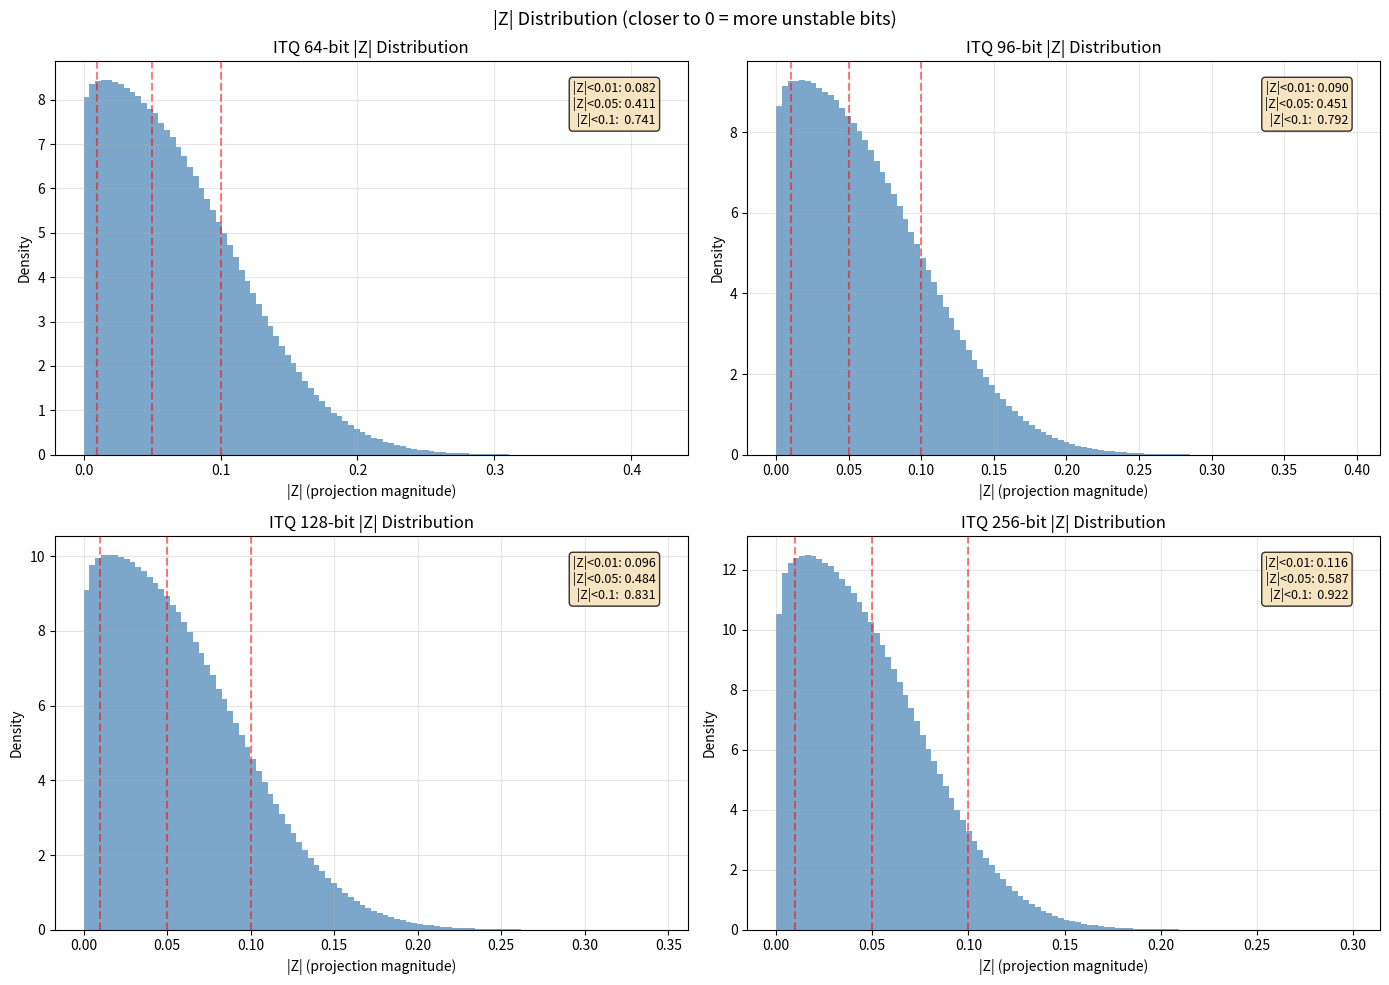


不安定ビット率:
     <0.01  <0.05   <0.1
64  0.0824 0.4115 0.7405
96  0.0898 0.4508 0.7924
128 0.0960 0.4838 0.8313
256 0.1163 0.5870 0.9220


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
unstable_rates = {}

for idx, n_bits in enumerate(BIT_COUNTS):
    ax = axes[idx // 2][idx % 2]
    itq = itq_models[n_bits]
    
    # 射影値を計算: centered → PCA → ITQ rotation
    centered = embeddings - itq.mean_vector
    projected = centered @ itq.pca_matrix @ itq.rotation_matrix
    abs_z = np.abs(projected)
    
    # |Z| 分布のヒストグラム
    ax.hist(abs_z.ravel(), bins=100, density=True, color="steelblue", alpha=0.7)
    
    # 不安定ビット率（|Z| < 各閾値）
    thresholds = [0.01, 0.05, 0.1]
    for t in thresholds:
        rate = (abs_z < t).mean()
        ax.axvline(x=t, color="red", linestyle="--", alpha=0.5)
    
    unstable_01 = (abs_z < 0.01).mean()
    unstable_05 = (abs_z < 0.05).mean()
    unstable_10 = (abs_z < 0.1).mean()
    unstable_rates[n_bits] = {"<0.01": unstable_01, "<0.05": unstable_05, "<0.1": unstable_10}
    
    ax.set_title(f"ITQ {n_bits}-bit |Z| Distribution")
    ax.set_xlabel("|Z| (projection magnitude)")
    ax.set_ylabel("Density")
    ax.text(0.95, 0.95, f"|Z|<0.01: {unstable_01:.3f}\n|Z|<0.05: {unstable_05:.3f}\n|Z|<0.1:  {unstable_10:.3f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))
    ax.grid(True, alpha=0.3)

plt.suptitle("|Z| Distribution (closer to 0 = more unstable bits)", fontsize=13)
plt.tight_layout()
plt.show()

# 不安定ビット率のサマリー
import pandas as pd
print("\n不安定ビット率:")
print(pd.DataFrame(unstable_rates).T.to_string(float_format="%.4f"))

## 3. ビットエントロピー

各ビット位置のエントロピーを計算。理想値は 1.0（0/1 が均等）。

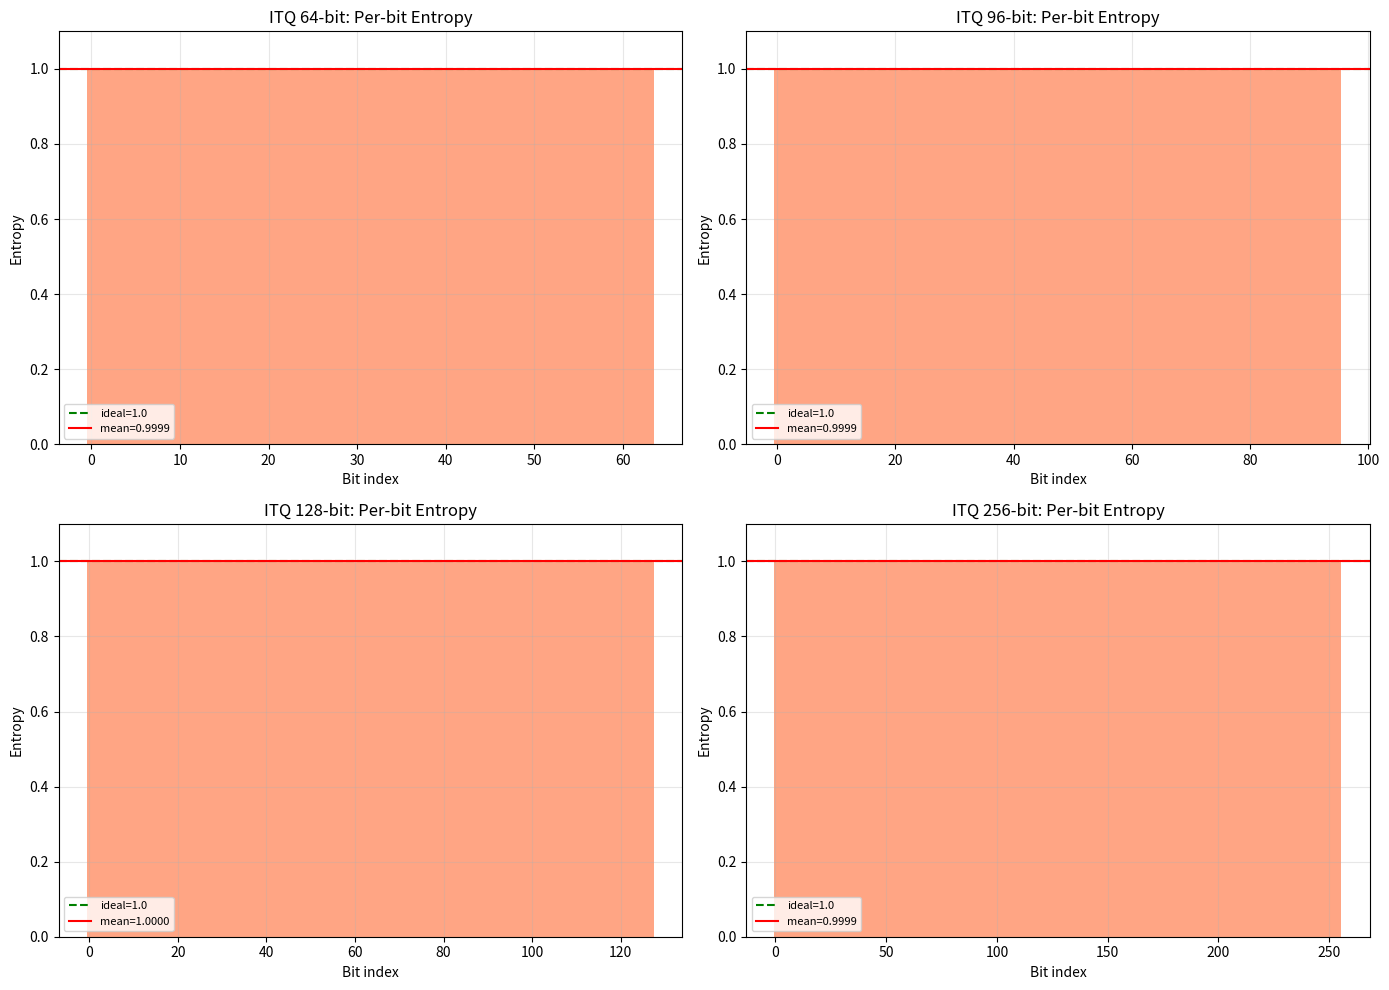


ビットエントロピー統計:
      mean    min    std
64  0.9999 0.9995 0.0001
96  0.9999 0.9993 0.0001
128 1.0000 0.9997 0.0001
256 0.9999 0.9994 0.0001


In [4]:
def bit_entropy(hashes):
    """各ビット位置のエントロピーを計算"""
    p = hashes.mean(axis=0)  # 各ビットが1になる確率
    # クリップしてlog(0)を回避
    p = np.clip(p, 1e-10, 1 - 1e-10)
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
entropy_stats = {}

for idx, n_bits in enumerate(BIT_COUNTS):
    ax = axes[idx // 2][idx % 2]
    hashes = binary_hashes[n_bits]
    
    entropies = bit_entropy(hashes)
    mean_ent = entropies.mean()
    min_ent = entropies.min()
    entropy_stats[n_bits] = {"mean": mean_ent, "min": min_ent, "std": entropies.std()}
    
    ax.bar(range(n_bits), entropies, color="coral", width=1.0, alpha=0.7)
    ax.axhline(y=1.0, color="green", linestyle="--", label="ideal=1.0")
    ax.axhline(y=mean_ent, color="red", linestyle="-", label=f"mean={mean_ent:.4f}")
    ax.set_xlabel("Bit index")
    ax.set_ylabel("Entropy")
    ax.set_title(f"ITQ {n_bits}-bit: Per-bit Entropy")
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nビットエントロピー統計:")
print(pd.DataFrame(entropy_stats).T.to_string(float_format="%.4f"))

## 4. SimHash vs ITQ 比較（Spearman 相関）

128bit で SimHash とITQ のハミング距離 ↔ コサイン類似度の相関を比較。

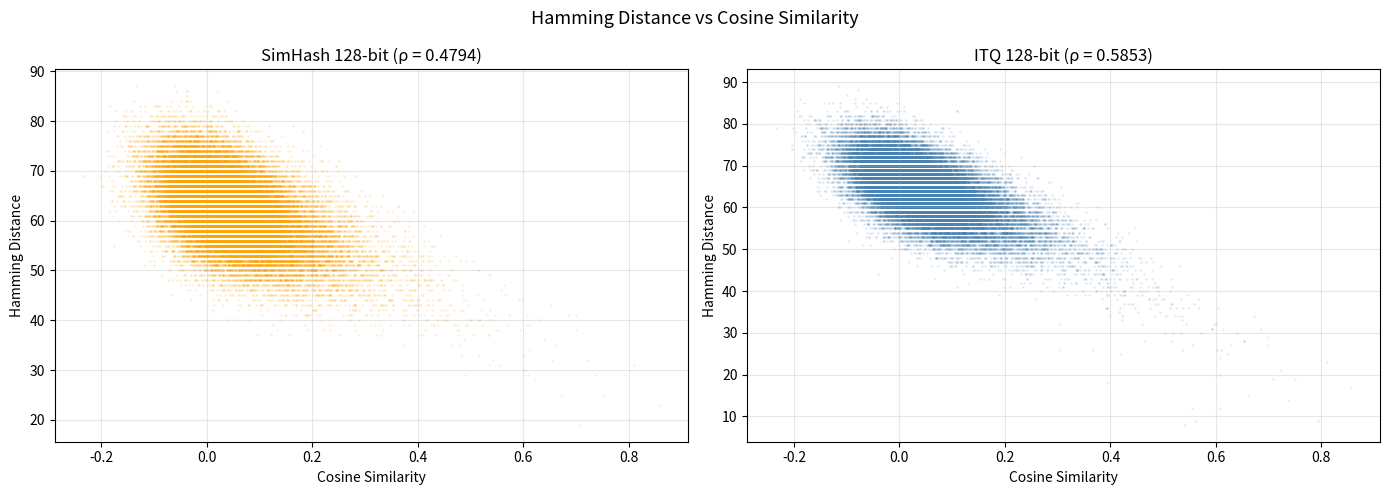

SimHash 128-bit: Spearman ρ = 0.4794
ITQ    128-bit: Spearman ρ = 0.5853
ITQ の改善: +0.1059


In [5]:
rng = np.random.default_rng(42)

# SimHash 128bit
simhash_gen = SimHashGenerator(dim=512, hash_bits=128, seed=42)
simhash_ints = simhash_gen.hash_batch(embeddings)

# テスト用ペア生成
n_test = 3000
test_idx = rng.choice(len(embeddings), n_test, replace=False)
n_pairs = 50_000
p1 = rng.choice(n_test, n_pairs)
p2 = rng.choice(n_test, n_pairs)
mask = p1 != p2
p1, p2 = p1[mask], p2[mask]

# コサイン類似度
cos_sims = np.sum(embeddings[test_idx[p1]] * embeddings[test_idx[p2]], axis=1)

# ITQ 128bit ハミング距離
itq_hashes = binary_hashes[128][test_idx]
itq_hamming = np.sum(itq_hashes[p1] != itq_hashes[p2], axis=1)

# SimHash ハミング距離
sh_hashes_test = [simhash_ints[test_idx[i]] for i in range(n_test)]
sh_hamming_dists = np.array([sh_hamming(sh_hashes_test[i], sh_hashes_test[j]) for i, j in zip(p1, p2)])

# Spearman 相関
rho_itq, _ = spearmanr(cos_sims, -itq_hamming)
rho_sh, _ = spearmanr(cos_sims, -sh_hamming_dists)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(cos_sims, sh_hamming_dists, s=1, alpha=0.1, color="orange")
axes[0].set_xlabel("Cosine Similarity")
axes[0].set_ylabel("Hamming Distance")
axes[0].set_title(f"SimHash 128-bit (ρ = {rho_sh:.4f})")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(cos_sims, itq_hamming, s=1, alpha=0.1, color="steelblue")
axes[1].set_xlabel("Cosine Similarity")
axes[1].set_ylabel("Hamming Distance")
axes[1].set_title(f"ITQ 128-bit (ρ = {rho_itq:.4f})")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Hamming Distance vs Cosine Similarity", fontsize=13)
plt.tight_layout()
plt.show()

print(f"SimHash 128-bit: Spearman ρ = {rho_sh:.4f}")
print(f"ITQ    128-bit: Spearman ρ = {rho_itq:.4f}")
print(f"ITQ の改善: +{rho_itq - rho_sh:.4f}")

## 5. 全ビット数でのハミング距離 vs コサイン類似度

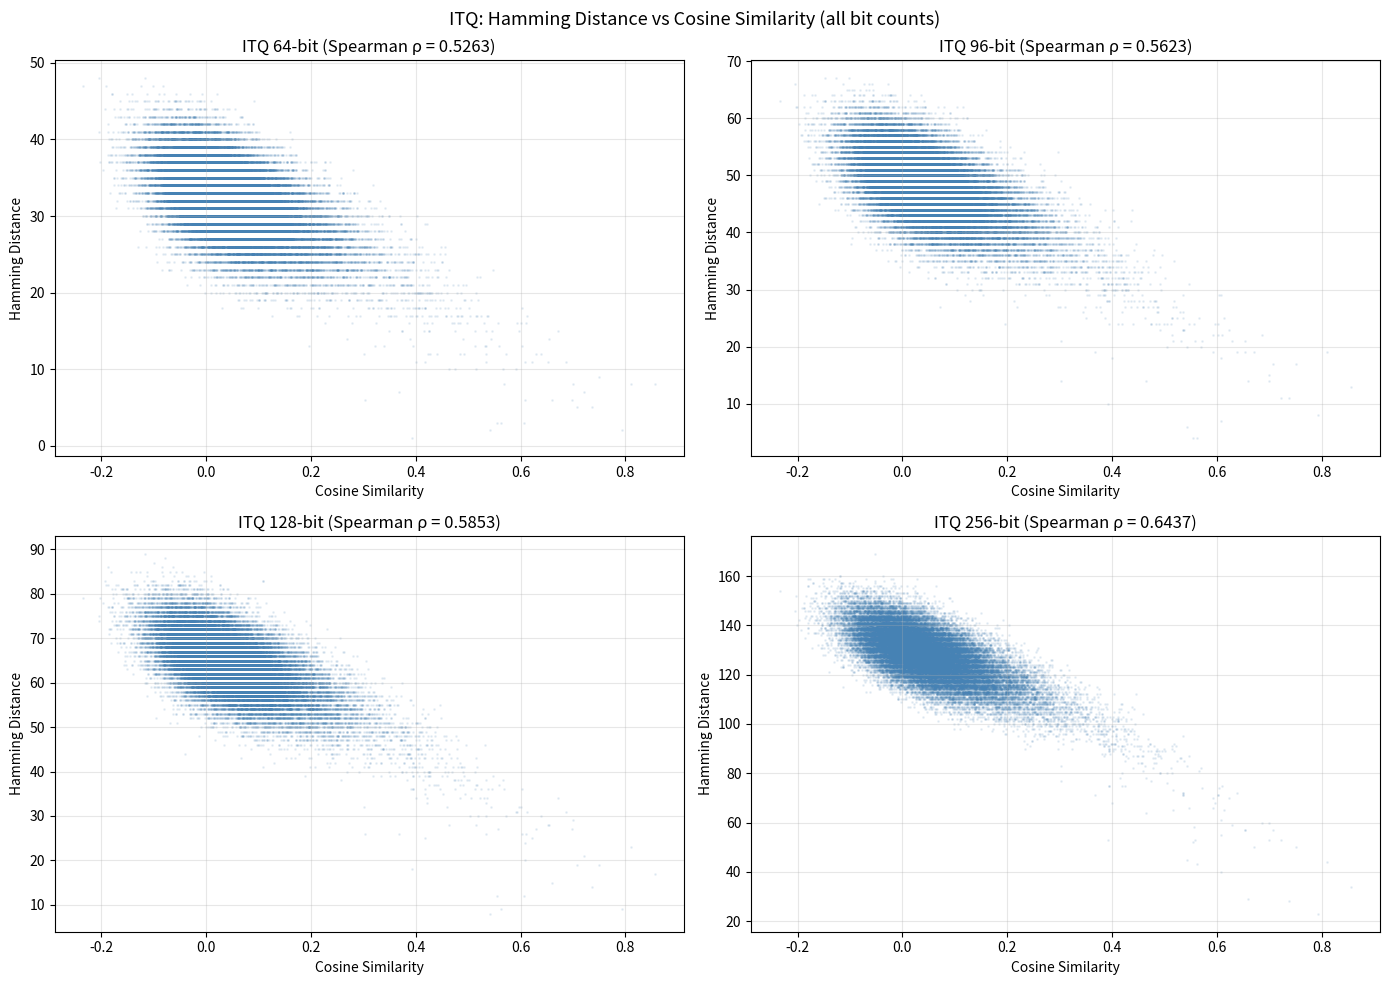


Spearman ρ (cosine sim vs -hamming dist):
   64 bits: ρ = 0.5263
   96 bits: ρ = 0.5623
  128 bits: ρ = 0.5853
  256 bits: ρ = 0.6437

ベスト: 256 bits (ρ = 0.6437)


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
spearman_results = {}

for idx, n_bits in enumerate(BIT_COUNTS):
    ax = axes[idx // 2][idx % 2]
    
    hashes_test = binary_hashes[n_bits][test_idx]
    ham_dists = np.sum(hashes_test[p1] != hashes_test[p2], axis=1)
    
    rho, pval = spearmanr(cos_sims, -ham_dists)
    spearman_results[n_bits] = rho
    
    ax.scatter(cos_sims, ham_dists, s=1, alpha=0.1, color="steelblue")
    ax.set_xlabel("Cosine Similarity")
    ax.set_ylabel("Hamming Distance")
    ax.set_title(f"ITQ {n_bits}-bit (Spearman ρ = {rho:.4f})")
    ax.grid(True, alpha=0.3)

plt.suptitle("ITQ: Hamming Distance vs Cosine Similarity (all bit counts)", fontsize=13)
plt.tight_layout()
plt.show()

print("\nSpearman ρ (cosine sim vs -hamming dist):")
for n_bits, rho in spearman_results.items():
    print(f"  {n_bits:3d} bits: ρ = {rho:.4f}")
best_bits = max(spearman_results, key=spearman_results.get)
print(f"\nベスト: {best_bits} bits (ρ = {spearman_results[best_bits]:.4f})")

## 6. サマリー

In [7]:
# 全メトリクスのサマリーテーブル
summary_data = []
for n_bits in BIT_COUNTS:
    summary_data.append({
        "bits": n_bits,
        "bit_balance": binary_hashes[n_bits].mean(),
        "mean_entropy": entropy_stats[n_bits]["mean"],
        "min_entropy": entropy_stats[n_bits]["min"],
        "unstable_01": unstable_rates[n_bits]["<0.01"],
        "unstable_05": unstable_rates[n_bits]["<0.05"],
        "spearman_rho": spearman_results[n_bits],
    })

summary_df = pd.DataFrame(summary_data).set_index("bits")
print("=" * 60)
print("ITQ ハッシュ品質サマリー")
print("=" * 60)
print(summary_df.to_string(float_format="%.4f"))

print(f"\nSimHash 128-bit Spearman ρ: {rho_sh:.4f}")
print(f"ITQ    128-bit Spearman ρ: {rho_itq:.4f}")

print(f"\n推奨ビット数: {best_bits} bits")
print(f"保存先: {MODEL_DIR}/itq_arcface_*bit.pkl")
print("\n→ NB93 でカスケード検索の精度評価へ進む")

ITQ ハッシュ品質サマリー
      bit_balance  mean_entropy  min_entropy  unstable_01  unstable_05  spearman_rho
bits                                                                                
64         0.4994        0.9999       0.9995       0.0824       0.4115        0.5263
96         0.4995        0.9999       0.9993       0.0898       0.4508        0.5623
128        0.5001        1.0000       0.9997       0.0960       0.4838        0.5853
256        0.4998        0.9999       0.9994       0.1163       0.5870        0.6437

SimHash 128-bit Spearman ρ: 0.4794
ITQ    128-bit Spearman ρ: 0.5853

推奨ビット数: 256 bits
保存先: ../data/itq_models/itq_arcface_*bit.pkl

→ NB93 でカスケード検索の精度評価へ進む


## 評価・考察

### ハッシュ品質
- **ビットバランス**: 全ビット数で ~0.500（ほぼ理想的）。ITQ の回転最適化が均等なビット配分を実現
- **ビットエントロピー**: 全ビット数で mean≈1.000、min≥0.999。各ビットが最大限の情報量を持つ
- **不安定ビット率**: |Z|<0.1 で 74〜92%と高い。512次元→64〜256次元への次元圧縮のため、射影値が小さくなりやすい。ただしカスケード検索（リランキング付き）ではこの不安定性は候補選択段階の問題にとどまる

### SimHash vs ITQ
- **ITQ 128bit ρ=0.585 vs SimHash ρ=0.479**: ITQ が +0.106 改善。PCA による主成分抽出と回転最適化の効果が明確
- ただし ρ=0.585 はテキスト埋め込み (E5) での結果と比較するとやや低い。512次元で有効次元数154（30%）であることと、128bit で累積寄与率70.3%にとどまることが要因

### ビット数の選択
- **256bit (ρ=0.644)** が最良だが、128bit との差は +0.058。カスケードでのリランキングで十分カバー可能
- **128bit** がハッシュサイズ（16バイト）とのバランスで推奨。バンドインデックスやPivotフィルタとの組み合わせでも扱いやすい
- 64bit はρ=0.526と低く、特に高類似度領域での精度劣化が懸念される